In [124]:
import json
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
import torch

# 1. Создание датасета

In [125]:

data = [
    {"text": "первое предложение", "список тегов": ["tag_1"]},
    {"text": "второе предложение", "список тегов": ["tag_1", "tag_2", "tag_3"]},
    {"text": "третье предложение", "список тегов": ["tag_1"]},
    {"text": "четвёртое предложение", "список тегов": ["tag_1"]},
    {"text": "пятое предложение", "список тегов": ["tag_1, tag_2"]},
    {"text": "шестоё предложение", "список тегов": ["tag_1"]},
    {"text": "седьмое предложение", "список тегов": ["tag_2, tag_3"]},
    {"text": "восьмое предложение", "список тегов": ["tag_1"]},
    {"text": "девятое предложение", "список тегов": ["tag_1"]},
    {"text": "десятое предложение", "список тегов": ["tag_1"]}
]
with open('data/test.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, ensure_ascii=False, indent=2)  # indent для красивого форматирования

# 2. Извлечение данных

In [126]:
df = pd.read_json("data/test.json")
df

,text,список тегов
0,первое предложение,[tag_1]
1,второе предложение,"[tag_1, tag_2, tag_3]"
2,третье предложение,[tag_1]
3,четвёртое предложение,[tag_1]
4,пятое предложение,"[tag_1, tag_2]"
5,шестоё предложение,[tag_1]
6,седьмое предложение,"[tag_2, tag_3]"
7,восьмое предложение,[tag_1]
8,девятое предложение,[tag_1]
9,десятое предложение,[tag_1]


In [127]:
# Извлечение текстов и тегов
texts = [item['text'] for item in data]
tags = [item['список тегов'] for item in data]

In [128]:
print(f"Список текстов:{texts}")
print(f"Список тегов:{tags}")

Список текстов:['первое предложение', 'второе предложение', 'третье предложение', 'четвёртое предложение', 'пятое предложение', 'шестоё предложение', 'седьмое предложение', 'восьмое предложение', 'девятое предложение', 'десятое предложение']
Список тегов:[['tag_1'], ['tag_1', 'tag_2', 'tag_3'], ['tag_1'], ['tag_1'], ['tag_1, tag_2'], ['tag_1'], ['tag_2, tag_3'], ['tag_1'], ['tag_1'], ['tag_1']]


In [129]:
tags

[['tag_1'],
 ['tag_1', 'tag_2', 'tag_3'],
 ['tag_1'],
 ['tag_1'],
 ['tag_1, tag_2'],
 ['tag_1'],
 ['tag_2, tag_3'],
 ['tag_1'],
 ['tag_1'],
 ['tag_1']]

In [130]:
# Загрузка данных из JSON
with open('test.json', 'r', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]

# Извлечение текстов и тегов
texts = [item['text'] for item in data]
tags = [item['список тегов'] for item in data]

FileNotFoundError: [Errno 2] No such file or directory: 'test.json'

# 3. Получение BERT-эмбеддингов с Mean Pooling

In [131]:
# Загрузка модели и токенизатора
# использовать bert-base-multilingual-cased !!!
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
model = AutoModel.from_pretrained("cointegrated/rubert-tiny2")

def get_bert_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Mean pooling с учетом attention_mask
    attention_mask = inputs['attention_mask']
    last_hidden_state = outputs.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return sum_embeddings / sum_mask

# Получение эмбеддингов для всех текстов
embeddings = torch.stack([get_bert_embedding(text) for text in texts]).squeeze(1)
embeddings = embeddings.numpy()  # Преобразование в numpy array

# 4.Уменьшение размерности (UMAP)

In [132]:
from umap import UMAP

# Уменьшение до 2D для визуализации
# n_neighbors - кол-во соседей, n_components - размерность, random_state задаём для воспроизведения результатов
umap = UMAP(n_neighbors=2, n_components=2, random_state=42)
embeddings_2d = umap.fit_transform(embeddings)

D:\Artem\Magistrature\1_sem\intellg_systems_and_techno\labs\.venv\Lib\site-packages\umap\umap_.py:1945: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



# 5. Кластеризация (K-Means)

In [133]:
from sklearn.cluster import KMeans

# Определение числа кластеров по количеству уникальных тегов
n_clusters = len(set(tag for sublist in tags for tag in sublist))
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(embeddings)

# 6. Визуализация (Plotly)

In [134]:
import plotly.express as px

# Подготовка данных для визуализации
df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'text': texts,
    'cluster': clusters,
    'tags': [', '.join(tag_list) for tag_list in tags]
})
# Интерактивная визуализация
fig = px.scatter(
    df,
    x='x',
    y='y',
    color='cluster',
    hover_name='text',
    hover_data=['tags'],
    title='Кластеризация предложений с BERT-эмбеддингами',
    width=1000,
    height=600
)
fig.update_traces(marker=dict(size=12, opacity=0.7))
fig.show()

7. Дополнительная визуализация (Matplotlib)

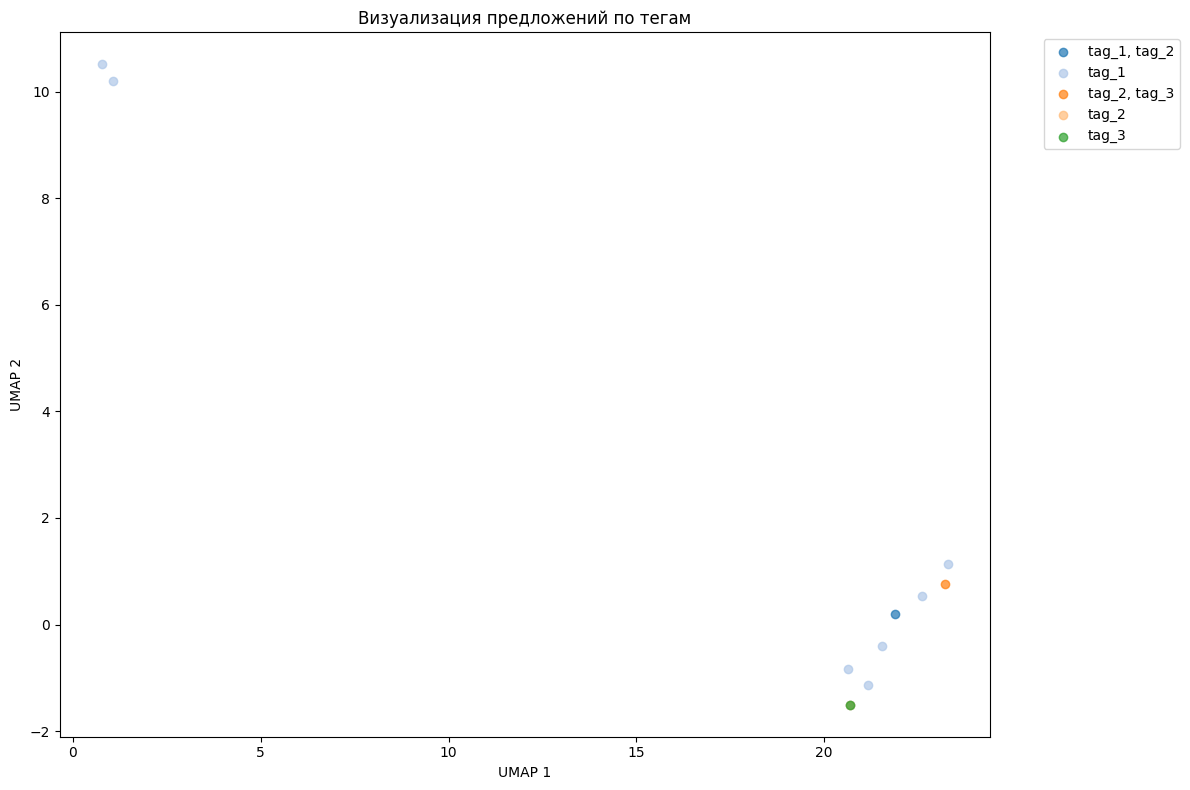

In [135]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Создание цветовой карты для тегов
unique_tags = list(set(tag for sublist in tags for tag in sublist))
cmap = ListedColormap(plt.cm.tab20.colors[:len(unique_tags)])

# Создание графика
plt.figure(figsize=(12, 8))
for i, tag in enumerate(unique_tags):
    mask = [tag in tag_list for tag_list in tags]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        color=cmap(i),
        label=tag,
        alpha=0.7
    )

plt.title('Визуализация предложений по тегам')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 8. Анализ результатов

In [136]:
# Анализ типичных слов в кластерах
from collections import Counter

for cluster_id in range(n_clusters):
    cluster_texts = [text for text, cluster in zip(texts, clusters) if cluster == cluster_id]
    all_words = ' '.join(cluster_texts).split()
    common_words = Counter(all_words).most_common(5)
    print(f"Кластер {cluster_id}: {common_words}")

Кластер 0: [('предложение', 6), ('третье', 1), ('четвёртое', 1), ('пятое', 1), ('шестоё', 1)]
Кластер 1: [('десятое', 1), ('предложение', 1)]
Кластер 2: [('первое', 1), ('предложение', 1)]
Кластер 3: [('девятое', 1), ('предложение', 1)]
Кластер 4: [('второе', 1), ('предложение', 1)]


In [137]:
# Вывод кол-ва тегов в каждом классе
# Предположим, у вас уже есть:
# - clusters - массив с номерами кластеров для каждого предложения
# - tags - список списков тегов для каждого предложения
# - n_clusters - количество кластеров

# Создаем DataFrame для удобства анализа
df_clusters = pd.DataFrame({
    'cluster': clusters,
    'tags': tags
})

# Анализируем теги в каждом кластере
for cluster_id in range(n_clusters):
    # Выбираем теги только для текущего кластера
    cluster_tags = df_clusters[df_clusters['cluster'] == cluster_id]['tags']
    
    # Собираем все теги в один список
    all_tags = [tag for sublist in cluster_tags for tag in sublist]
    
    # Считаем частоту каждого тега
    tag_counts = Counter(all_tags)
    
    # Выводим результаты
    print(f"\nКластер {cluster_id}:")
    print(f"Всего тегов: {len(all_tags)}")
    print(f"Уникальных тегов: {len(tag_counts)}")
    print("Частота тегов:")
    for tag, count in tag_counts.most_common():
        print(f"  {tag}: {count} раз(а)")


Кластер 0:
Всего тегов: 6
Уникальных тегов: 3
Частота тегов:
  tag_1: 4 раз(а)
  tag_1, tag_2: 1 раз(а)
  tag_2, tag_3: 1 раз(а)

Кластер 1:
Всего тегов: 1
Уникальных тегов: 1
Частота тегов:
  tag_1: 1 раз(а)

Кластер 2:
Всего тегов: 1
Уникальных тегов: 1
Частота тегов:
  tag_1: 1 раз(а)

Кластер 3:
Всего тегов: 1
Уникальных тегов: 1
Частота тегов:
  tag_1: 1 раз(а)

Кластер 4:
Всего тегов: 3
Уникальных тегов: 3
Частота тегов:
  tag_1: 1 раз(а)
  tag_2: 1 раз(а)
  tag_3: 1 раз(а)


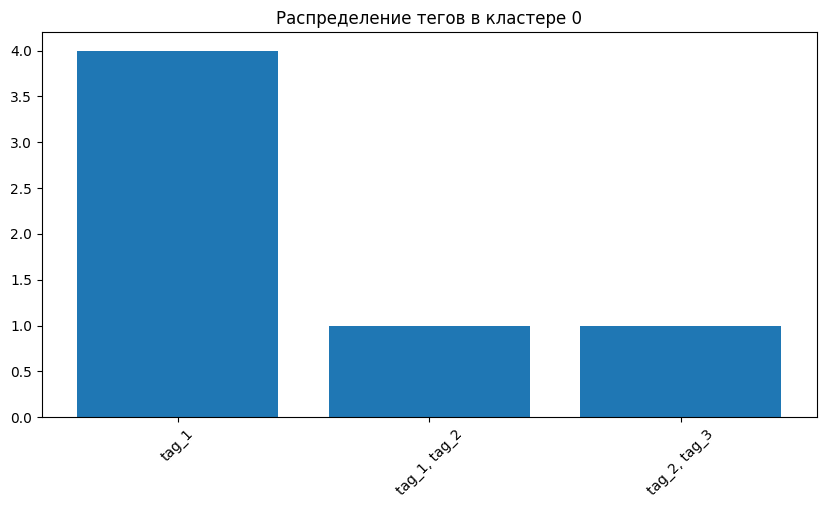

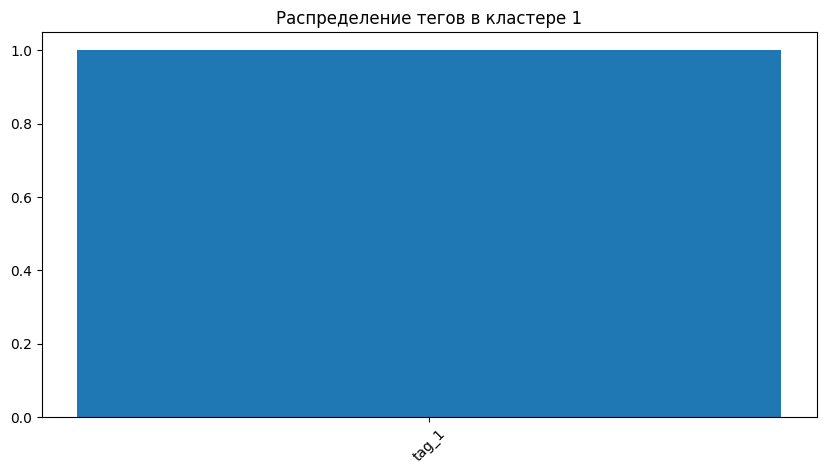

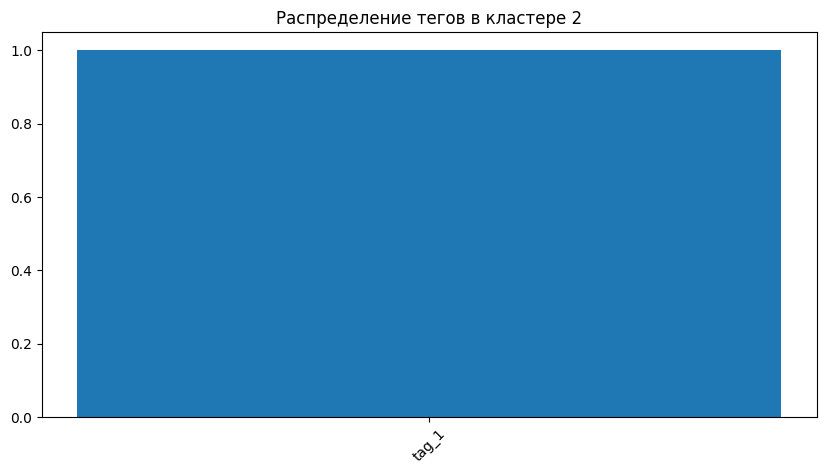

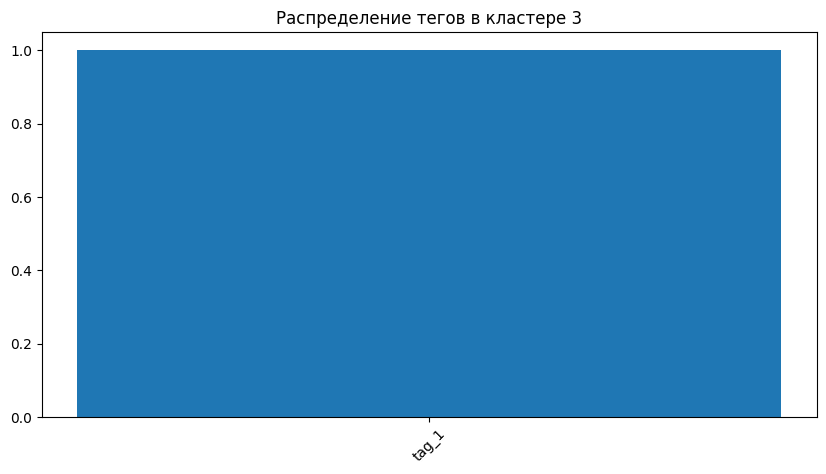

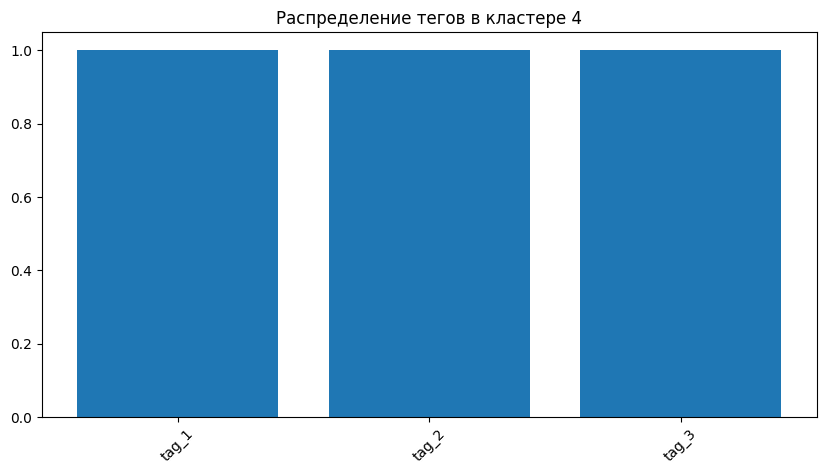

In [138]:
# Визуализация распределения тегов:
import matplotlib.pyplot as plt

for cluster_id in range(n_clusters):
    cluster_tags = df_clusters[df_clusters['cluster'] == cluster_id]['tags']
    all_tags = [tag for sublist in cluster_tags for tag in sublist]
    tag_counts = Counter(all_tags)
    
    tags, counts = zip(*tag_counts.most_common())
    
    plt.figure(figsize=(10, 5))
    plt.bar(tags, counts)
    plt.title(f'Распределение тегов в кластере {cluster_id}')
    plt.xticks(rotation=45)
    plt.show()

In [139]:
df_clusters

,cluster,tags
0,2,[tag_1]
1,4,"[tag_1, tag_2, tag_3]"
2,0,[tag_1]
3,0,[tag_1]
4,0,"[tag_1, tag_2]"
5,0,[tag_1]
6,0,"[tag_2, tag_3]"
7,0,[tag_1]
8,3,[tag_1]
9,1,[tag_1]


tags     tag_1  tag_1, tag_2  tag_1, tag_2, tag_3  tag_2, tag_3
cluster                                                        
0            4             1                    0             1
1            1             0                    0             0
2            1             0                    0             0
3            1             0                    0             0
4            0             0                    1             0


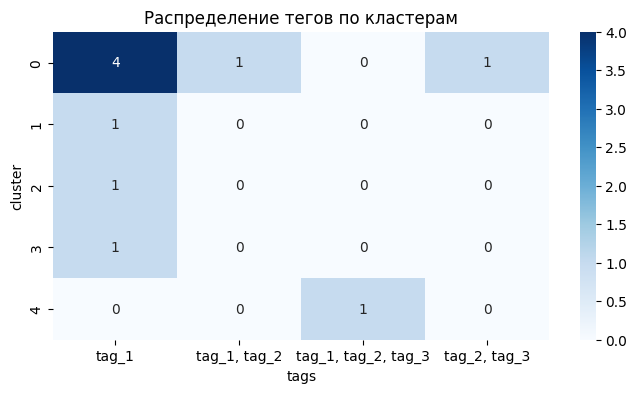

In [140]:
# Построение таблицы сопряженности:
# Создаем таблицу сопряженности тегов и кластеров
import seaborn as sns
cross_tab = (df.explode('tags')
               .groupby(['cluster', 'tags'])
               .size()
               .unstack(fill_value=0))
print(cross_tab)
plt.figure(figsize=(8, 4))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Распределение тегов по кластерам')
plt.show()

In [141]:
from collections import defaultdict
# Пример данных
data = [
    {"text": "первое предложение", "tags": ["tag_1"]},
    {"text": "второе предложение", "tags": ["tag_1", "tag_2"]},
    {"text": "третье предложение", "tags": ["tag_2", "tag_3"]},
    {"text": "четвертое предложение", "tags": ["tag_1", "tag_3"]}
]


# Собираем статистику
cluster_tag_stats = defaultdict(lambda: defaultdict(int))
global_tag_stats = defaultdict(int)

for cluster, tag_list in zip(clusters, [item["tags"] for item in data]):
    for tag in tag_list:
        cluster_tag_stats[cluster][tag] += 1
        global_tag_stats[tag] += 1
        

# Вычисляем характерность тегов
characteristic_tags = {}
for cluster in cluster_tag_stats:
    total_in_cluster = sum(cluster_tag_stats[cluster].values())
    tag_scores = {}
    
    for tag in cluster_tag_stats[cluster]:
        # Добавьте в цикл вычисления score:
        if global_tag_stats[tag] < 2:  # Игнорируем теги, встречающиеся < 2 раз
            continue
        # Доля тега в кластере относительно всех тегов
        cluster_ratio = cluster_tag_stats[cluster][tag] / total_in_cluster
        
        # Доля тега в других кластерах
        other_occurrences = global_tag_stats[tag] - cluster_tag_stats[cluster][tag]
        total_other = sum(sum(tags.values()) for c, tags in cluster_tag_stats.items() if c != cluster)
        other_ratio = other_occurrences / total_other if total_other > 0 else 0
        
        # Score = отношение частоты в кластере к частоте вне кластера
        score = cluster_ratio / (other_ratio + 1e-9)  # +1e-9 чтобы избежать деления на 0
        tag_scores[tag] = score
    
    characteristic_tags[cluster] = sorted(tag_scores.items(), key=lambda x: -x[1])

# Форматируем результат
results = []
for cluster in characteristic_tags:
    for tag, score in characteristic_tags[cluster][:3]:  # Топ-3 тега
        results.append({
            "Кластер": cluster,
            "Тег": tag,
            "Score": round(score, 2),
            "Частота в кластере": cluster_tag_stats[cluster][tag],
            "Частота в других кластерах": global_tag_stats[tag] - cluster_tag_stats[cluster][tag]
        })

# Создаем красивый DataFrame
df_results = pd.DataFrame(results)
print(df_results.sort_values(["Кластер", "Score"], ascending=[True, False]))

   Кластер    Тег         Score  Частота в кластере  \
3        0  tag_3  5.000000e+08                   2   
4        0  tag_2  7.500000e-01                   1   
5        0  tag_1  3.700000e-01                   1   
0        2  tag_1  3.000000e+00                   1   
1        4  tag_2  2.500000e+00                   1   
2        4  tag_1  1.250000e+00                   1   

   Частота в других кластерах  
3                           0  
4                           1  
5                           2  
0                           2  
1                           1  
2                           2  


In [142]:
df_results.sort_values(["Кластер", "Score"], ascending=[True, False])

,Кластер,Тег,Score,Частота в кластере,Частота в других кластерах
3,0,tag_3,5.000000e+08,2,0
4,0,tag_2,7.500000e-01,1,1
5,0,tag_1,3.700000e-01,1,2
0,2,tag_1,3.000000e+00,1,2
1,4,tag_2,2.500000e+00,1,1
2,4,tag_1,1.250000e+00,1,2


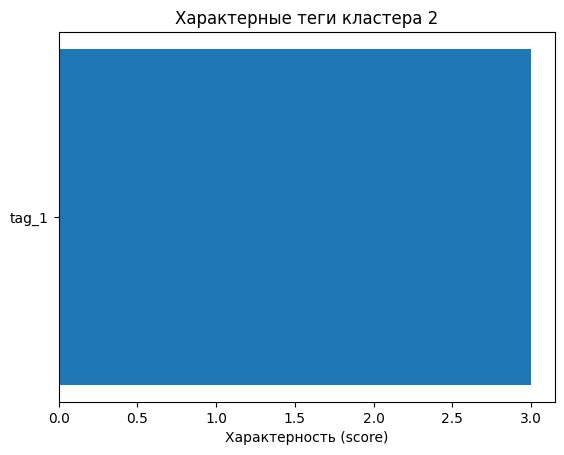

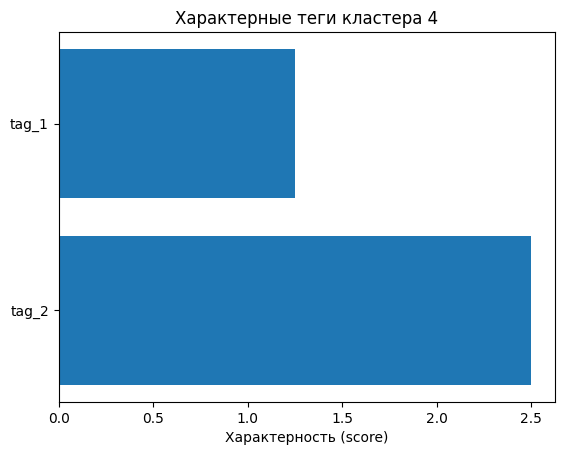

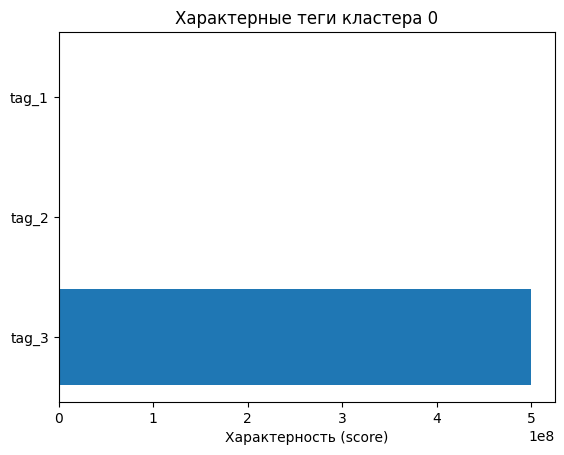

In [143]:
for cluster in characteristic_tags:
    tags, scores = zip(*characteristic_tags[cluster][:5])
    plt.barh(tags, scores)
    plt.title(f"Характерные теги кластера {cluster}")
    plt.xlabel("Характерность (score)")
    plt.show()